# Tidy Data Project:

## Imorting Libraries and Dataset:

In [4]:
# load necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Choose dataset and load:
df = pd.read_csv("data/olympics_08_medalists.csv")
df.head()

,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
0,Aaron Armstrong,NaN,NaN,gold,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Peirsol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abdullo Tangriev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abeer Abdelrahman,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,bronze,NaN,NaN,NaN
4,Abhinav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This dataset contains each athlete that medaled at the 2008 olympic games. It tracks their name, gender, event, and what medal they recieved. 

This data is quite messy, and much to wide to handle. With the extreme variety of data, with 71 columns, its a very messy interface, because you have to look through each row until you find what gender and event each person has medaled in. Additionally, the vast majority of entries are NaN, because of this layout, which in an incredibly inefficient use of space. The fact that there is multiple variables in each column name (gender and sport) violates a key tidy data principle, and is something that needs fixing. I will transform this into a long format instead of wide, clean up the column names, and ensure that each column only has one variable. 

## Cleaning Dataset

In [17]:
df_melted = df.melt(
    id_vars = "medalist_name",
    var_name = "event",
    value_name = "medal"
)
# this combines all column names into one column called "event"
df_melted

,medalist_name,event,medal
0,Aaron Armstrong,male_archery,NaN
1,Aaron Peirsol,male_archery,NaN
2,Abdullo Tangriev,male_archery,NaN
3,Abeer Abdelrahman,male_archery,NaN
4,Abhinav,male_archery,NaN
...,...,...,...
131245,Éver Banega,male_greco-roman wrestling,NaN
131246,Ólafur Stefánsson,male_greco-roman wrestling,NaN
131247,Óscar Brayson,male_greco-roman wrestling,NaN
131248,Łukasz Pawłowski,male_greco-roman wrestling,NaN


In [9]:
df_melted = df_melted.dropna().copy()
#since so many cells are not applicable, since each athlete only medaled in one event, we have to drop those empty ones. 
df_melted

,medalist_name,event,medal,gender,sport
177,Bair Badënov,male_archery,bronze,male,archery
676,Ilario Di Buò,male_archery,silver,male,archery
682,Im Dong-hyun,male_archery,gold,male,archery
760,Jiang Lin,male_archery,bronze,male,archery
920,Lee Chang-hwan,male_archery,gold,male,archery
...,...,...,...,...,...
130932,Steeve Guénot,male_greco-roman wrestling,gold,male,greco-roman wrestling
131159,Yannick Szczepaniak,male_greco-roman wrestling,bronze,male,greco-roman wrestling
131162,Yavor Yanakiev,male_greco-roman wrestling,bronze,male,greco-roman wrestling
131200,Yury Patrikeyev,male_greco-roman wrestling,bronze,male,greco-roman wrestling


In [13]:
df_melted[['gender', 'sport']] = df_melted['event'].str.split('_', n = 1, expand = True)
# this is to add individual columns for each gender and sport.
df_melted

,medalist_name,event,medal,gender,sport
177,Bair Badënov,male_archery,bronze,male,archery
676,Ilario Di Buò,male_archery,silver,male,archery
682,Im Dong-hyun,male_archery,gold,male,archery
760,Jiang Lin,male_archery,bronze,male,archery
920,Lee Chang-hwan,male_archery,gold,male,archery
...,...,...,...,...,...
130932,Steeve Guénot,male_greco-roman wrestling,gold,male,greco-roman wrestling
131159,Yannick Szczepaniak,male_greco-roman wrestling,bronze,male,greco-roman wrestling
131162,Yavor Yanakiev,male_greco-roman wrestling,bronze,male,greco-roman wrestling
131200,Yury Patrikeyev,male_greco-roman wrestling,bronze,male,greco-roman wrestling


In [16]:
df_clean = df_melted.drop(columns = 'event')
# we can now remove the redundant "event" column, since gender and sport have been accounted for in separate columns.
df_clean

,medalist_name,medal,gender,sport
177,Bair Badënov,bronze,male,archery
676,Ilario Di Buò,silver,male,archery
682,Im Dong-hyun,gold,male,archery
760,Jiang Lin,bronze,male,archery
920,Lee Chang-hwan,gold,male,archery
...,...,...,...,...
130932,Steeve Guénot,gold,male,greco-roman wrestling
131159,Yannick Szczepaniak,bronze,male,greco-roman wrestling
131162,Yavor Yanakiev,bronze,male,greco-roman wrestling
131200,Yury Patrikeyev,bronze,male,greco-roman wrestling


In this section, I reshaped the dataset using the melft function to transform it into a long format rather than wide. After creating a single column that encompassed gender and sport, I used the str.split function to separate them into two individual ones. Finally, after dropping the rows with no observations of medailists, I was left with a clean, interpretable dataset, that enavles visualization and comparison. 
Following Tidy Data Principles: 
- Each Variable is in its own columnn
- Each observation (medal awarded) is in its own row


## Visualization

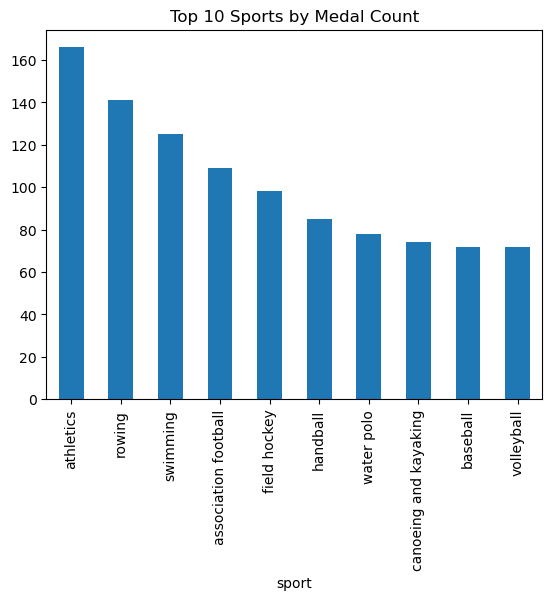

In [20]:
sport_counts = df_clean['sport'].value_counts().head(10)
# this is to visualize the top 10 sports in terms of medal counts
sport_counts.plot(kind = 'bar')
plt.title("Top 10 Sports by Medal Count")
plt.xticks(rotation = 90)
# ^ so the axis lables don't get too cluttered, rotate them. 
plt.show()

Athletics is the sport in which most medals were given out, issuing over 160. This was followed by rowing and swimming, then football and field hockey. Intuitively this result makes sense. The spoets with the highest medals issued are those like athletics and swimming where there are so many different events, and things like rowing, football and field hockey, where the team sizes are quite large, so it makes sense to have hundreds of athletes on the podiums for these. 

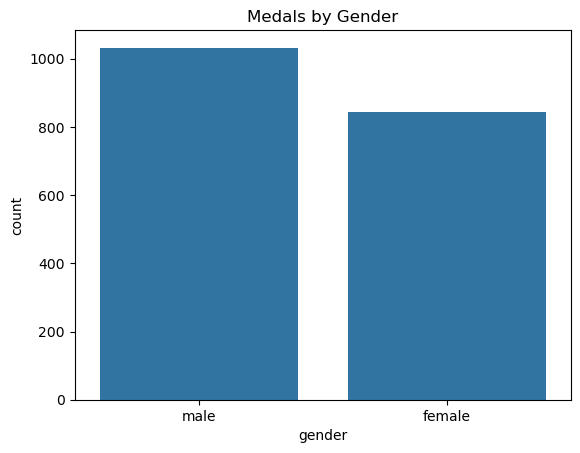

In [21]:
sns.countplot(data = df_clean, x = "gender")
# identifying medal count by each gender
plt.title("Medals by Gender")
plt.show()

There appears to be a large disparity between the amount of medals issued for men vs women, with roughly 200 going to men. 

In [25]:
# Looking to adress which sports are responsible for the disparity: 
# must begin by creating a pivot table: 
pivot = df_clean.pivot_table(
    index = "sport",
    #^ each row will represent a sport
    columns = "gender",
    values = "medal",
    # we need to count medals for each group:
    aggfunc = "count",
    fill_value = 0
)
pivot

gender,female,male
sport,,
archery,9,11
artistic gymnastics,20,29
association football,54,55
athletics,81,85
badminton,10,12
baseball,0,72
basketball,36,35
beach volleyball,6,6
bmx,3,3


Ths pivot table allows for observation of the difference in medal counts between males and femals for each respective sport. 

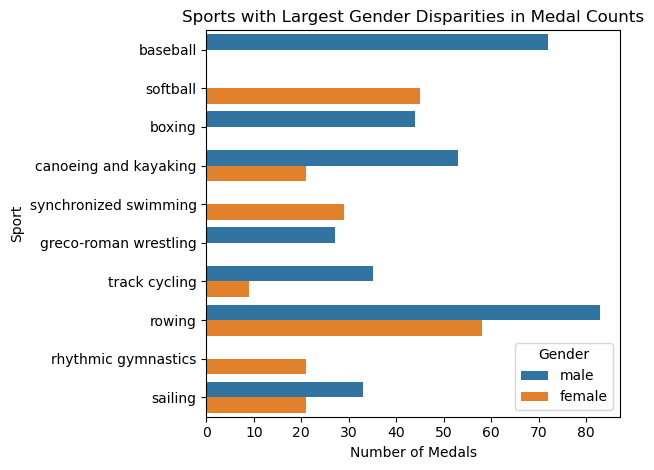

In [32]:
# Now measure the disparities: 
pivot['disparity'] = (pivot['male'] - pivot['female']).abs()
#^ captures the absolut differences between male and female for each sport
# isolate the highest ones:
top_disparity = pivot.sort_values(by = "disparity", ascending = False).head(10)
# filter through original dataset
filtered_df = df_clean[df_clean['sport'].isin(top_disparity.index)]

# make the visulization:
plt.figure()
sns.countplot(
    data = filtered_df,
    y = "sport",
    hue = "gender",
    order = top_disparity.index
)

plt.title("Sports with Largest Gender Disparities in Medal Counts")
plt.xlabel("Number of Medals")
plt.ylabel("Sport")
plt.legend(title = "Gender")
plt.tight_layout()
# ^ ensure everything is fully visible

plt.show()

It appears the higher amount of male medals is fueled by baseball, boxing, and wrestling, all of which are exclusively male sports. While sports like softball, gymnastics, and snycronized swimming apprear to have only women medalists, the magnitudes of the male sports are much larger. Even sports that have both male and female medalists tend to have much higher levels of male medalists. These factors explain the overall discrepency between male and female athletes. 

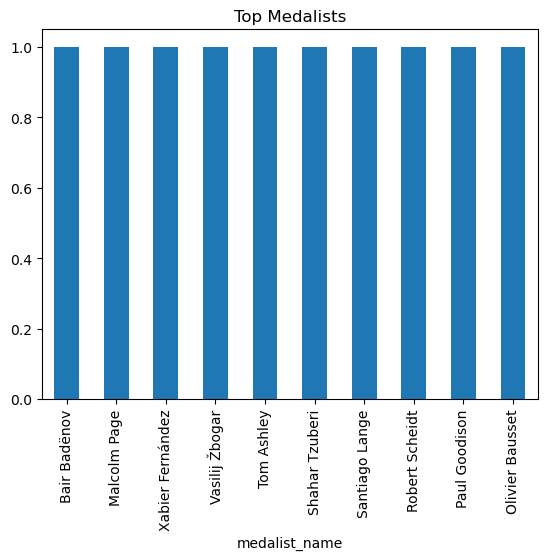

count    1875.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: count, dtype: float64

In [39]:
# Look for athletes who won more than one medal: 
top_athletes = df_clean['medalist_name'].value_counts().head(10)

top_athletes.plot(kind = 'bar')
plt.title("Top Medalists")
plt.show()
# confirm the max is only 1 for the the medalist names
df_clean['medalist_name'].value_counts().describe()

This visualization shows us that the dataset doesn't account for athletes that won more than one medal at the 2008 Olympic games. Each athlete only appears once. 